In [30]:
import kagglehub
import numpy as nm
import pandas as ps
import matplotlib.pyplot as plt
import seaborn as sb

# **Importing Data Of a Telecommunication Company For Analysis, Why customers churn**

In [31]:
df=ps.read_csv("/content/drive/MyDrive/Colab Notebooks/telco-churnData.csv")
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


# **Problem** : Find why customers leave

# **Data Review**

In [32]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [34]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [35]:
df= df.dropna()
df= df.drop_duplicates()
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


## **Data Cleaning :**

In [36]:
df['SeniorCitizen'] = df['SeniorCitizen'].astype(bool)
df['tenure'] = df['tenure'].astype(int).copy()
df['MonthlyCharges'] = ps.to_numeric(df['MonthlyCharges'], errors='coerce').copy()
df['TotalCharges'] = ps.to_numeric(df['TotalCharges'], errors='coerce').copy()

cols= ['Partner','Dependents','PhoneService','PaperlessBilling','Churn']

for col in cols :
  df[col]=df[col].map({'Yes' : 1 , 'No' : 0}).astype(bool)


df=df[['gender','SeniorCitizen','Partner','Dependents','tenure','PhoneService','MultipleLines','InternetService','StreamingTV','StreamingMovies','Contract','PaperlessBilling','PaymentMethod','MonthlyCharges','TotalCharges','Churn']]
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,False,True,False,1,False,No phone service,DSL,No,No,Month-to-month,True,Electronic check,29.85,29.85,False
1,Male,False,False,False,34,True,No,DSL,No,No,One year,False,Mailed check,56.95,1889.50,False
2,Male,False,False,False,2,True,No,DSL,No,No,Month-to-month,True,Mailed check,53.85,108.15,True
3,Male,False,False,False,45,False,No phone service,DSL,No,No,One year,False,Bank transfer (automatic),42.30,1840.75,False
4,Female,False,False,False,2,True,No,Fiber optic,No,No,Month-to-month,True,Electronic check,70.70,151.65,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,False,True,True,24,True,Yes,DSL,Yes,Yes,One year,True,Mailed check,84.80,1990.50,False
7039,Female,False,True,True,72,True,Yes,Fiber optic,Yes,Yes,One year,True,Credit card (automatic),103.20,7362.90,False
7040,Female,False,True,True,11,False,No phone service,DSL,No,No,Month-to-month,True,Electronic check,29.60,346.45,False
7041,Male,True,True,False,4,True,Yes,Fiber optic,No,No,Month-to-month,True,Mailed check,74.40,306.60,True


# **Data Analysis :**

**Gender Base Analysis**

Total Male Number :  3555 
Total Female Number :  3488

Total Male churned :  930 
Total Female churned :  939

Dependent Male with partner who churned :  117 
Dependent Female with partner who churned :  132



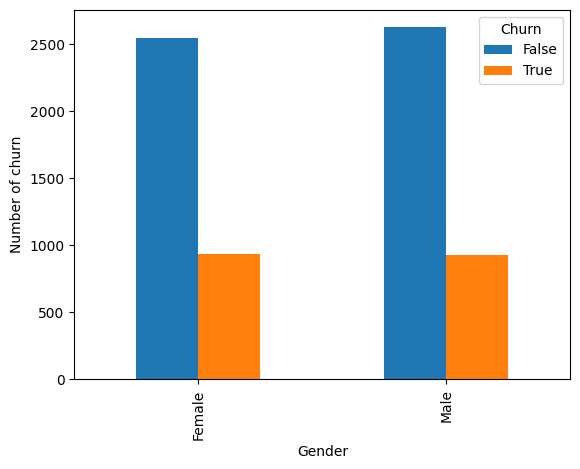

In [37]:
totalmale = (df['gender']=="Male").sum()
totalfemale = (df['gender']=="Female").sum()

print("Total Male Number : ",totalmale,"\nTotal Female Number : ",totalfemale)

churnmale = ((df['gender']=="Male") & (df['Churn']== True) ).sum()
churnfemale = ((df['gender']=="Female") & (df['Churn']== True)).sum()

print()
print("Total Male churned : ",churnmale,"\nTotal Female churned : ",churnfemale)


infomale = ((df['gender']=="Male") & (df['Partner'] == True ) & (df['Dependents'] == True) & (df['Churn']== True) ).sum()
infofemale = ((df['gender']=="Female") & (df['Partner'] == True ) & (df['Dependents'] == True) & (df['Churn']== True)).sum()

print()
print("Dependent Male with partner who churned : ",infomale,"\nDependent Female with partner who churned : ",infofemale)
print()

ploting1 = ps.crosstab(df['gender'], df['Churn']).plot(kind='bar',xlabel="Gender",ylabel="Number of churn")


**Insight : Female customers show slightly higher churn compared to males.**  
**Business Insight:** Advatise more to male customers.

**Analysis Accroding to Contract**

In [59]:
df.groupby("Contract")["Churn"].mean()

,Churn
Contract,
Month-to-month,0.427097
One year,0.112695
Two year,0.028319


In [39]:
contractminfo = ((df['Contract']=="Month-to-month") & (df['Churn']== True)).sum()
contract1info = ((df['Contract']=="One year") & (df['Churn']== True)).sum()
contract2info = ((df['Contract']=="Two year") & (df['Churn']== True)).sum()

print("Montly contract : ",contractminfo,"\n1 year contract : ",contract1info , "\n2 year contract : ",contract2info)

Montly contract :  1655 
1 year contract :  166 
2 year contract :  48


Text(0.5, 1.0, 'People Leaves our company as per contract')

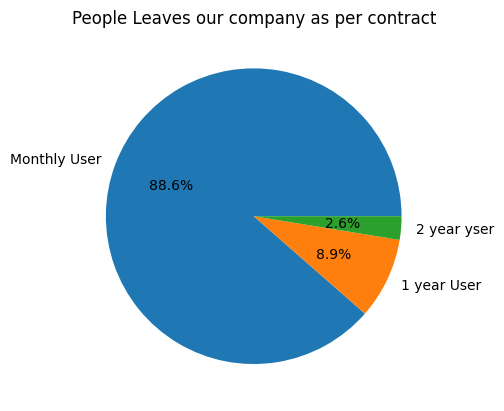

In [46]:
y=[contractminfo,contract1info,contract2info]
label = ["Monthly User","1 Year User","2 Year User"]

plt.pie(y,labels=label,autopct="%1.1f%%")
plt.title("People Leaves our company as per contract")

**We can see mostly , monthly user Churn.**                                                                           
**Business Insight :** You could give more 1 year or 2 year Contract Offers and stop promoting or discourage the Customers for buy monthly offers .

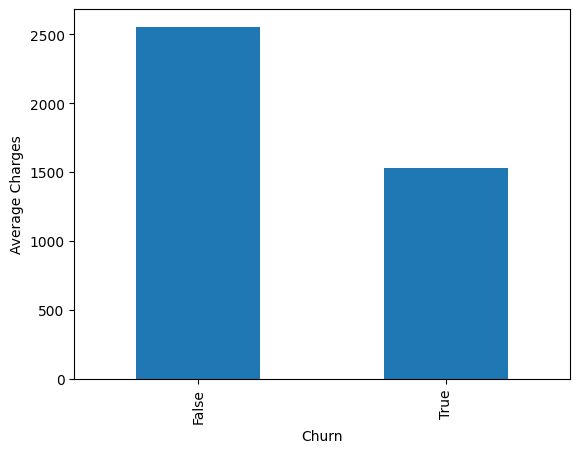

In [56]:
df.groupby("Churn")["TotalCharges"].mean().plot(kind="bar")
plt.ylabel("Average Charges")
plt.show()

**Churn customers Pay bills lower then Non-churn customers.**

In [58]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,False,True,False,1,False,No phone service,DSL,No,No,Month-to-month,True,Electronic check,29.85,29.85,False
1,Male,False,False,False,34,True,No,DSL,No,No,One year,False,Mailed check,56.95,1889.50,False
2,Male,False,False,False,2,True,No,DSL,No,No,Month-to-month,True,Mailed check,53.85,108.15,True
3,Male,False,False,False,45,False,No phone service,DSL,No,No,One year,False,Bank transfer (automatic),42.30,1840.75,False
4,Female,False,False,False,2,True,No,Fiber optic,No,No,Month-to-month,True,Electronic check,70.70,151.65,True


<Axes: xlabel='Churn'>

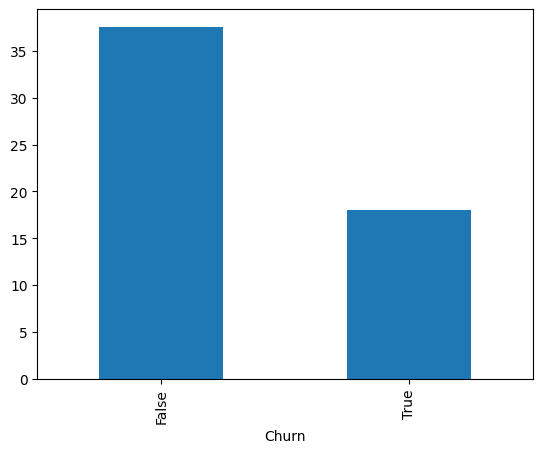

In [62]:
df.groupby("Churn")['tenure'].mean().plot(kind='bar')

**Insight : Customers with low tenure churn more.**

In [66]:
countp = ((df['PhoneService']==True) & (df['Churn']==True)).sum()
countq = ((df['PhoneService']==False) & (df['Churn']==True)).sum()

print(countp)
print(countq)

1699
170


([<matplotlib.patches.Wedge at 0x79df5b6f4c80>,
 [Text(-1.05539488120873, 0.310067161625366, 'Churn users with Phone Service'),
  Text(1.0553949083156593, -0.3100670693598103, 'Churn users without Phone Service')],
 [Text(-0.5756699352047617, 0.1691275427047451, '90.9%'),
  Text(0.5756699499903595, -0.16912749237807834, '9.1%')])

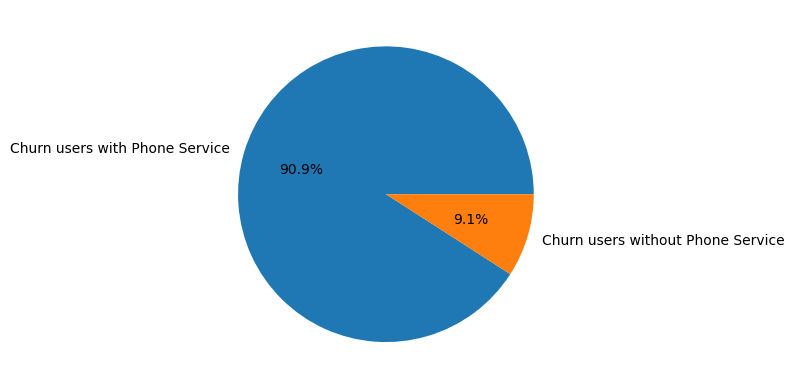

In [69]:
y=[countp,countq]
label=['Churn users with Phone Service','Churn users without Phone Service']

plt.pie(y,labels=label,autopct="%1.1f%%")

**Phone Service User are mostly churn.**

# Key Findings:
- Month-to-month users churn most .
- Low tenure users churn more .
- Churn users spend less .

# Recommendations:
- Encourage for long-term contracts to users.
- Target new users with offers for long term .  
- Improve early experience .